<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/MarketMicrostructure/MarketMicrostructure/High_Frequency_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

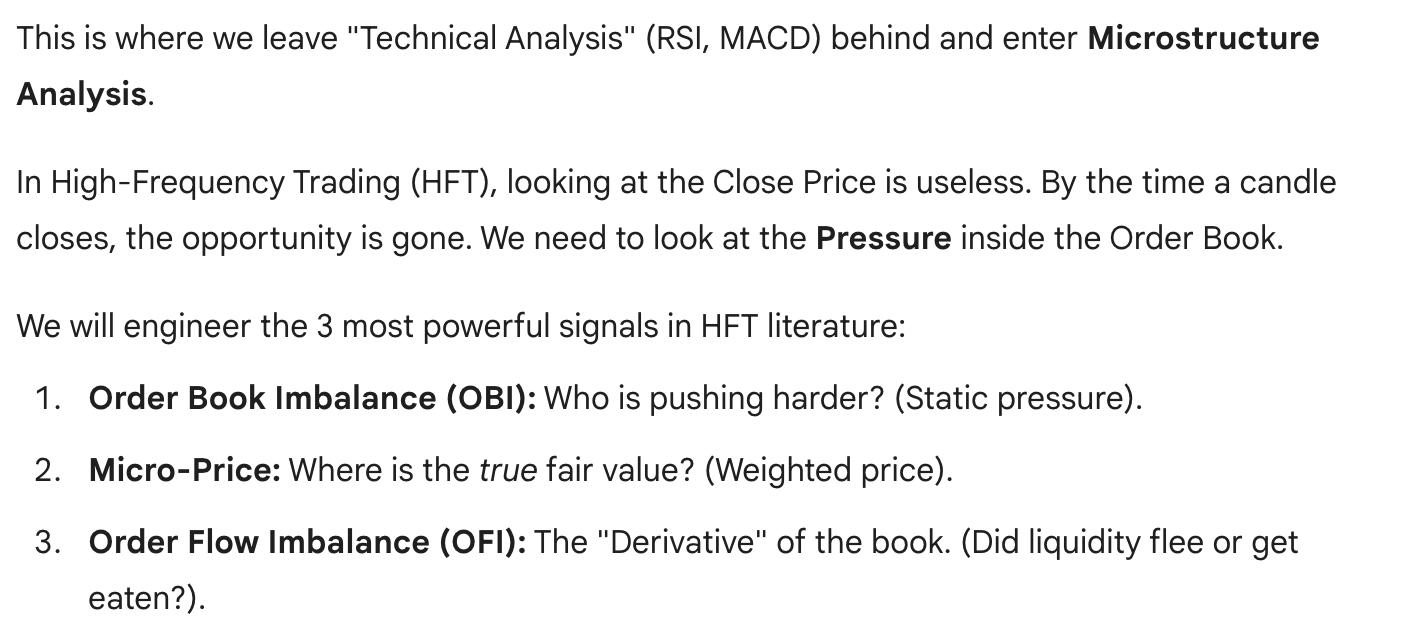

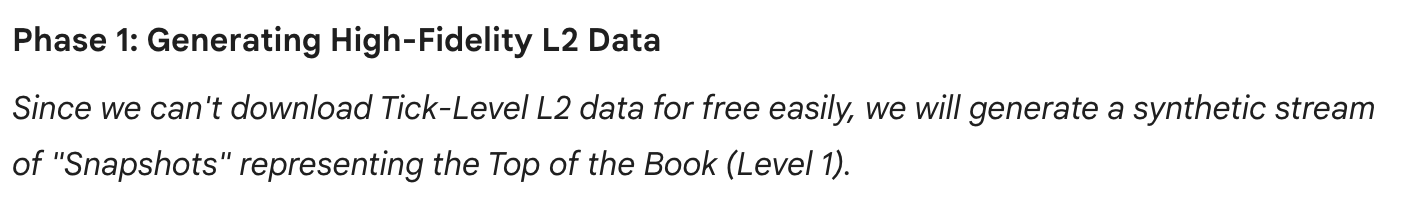

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- 1. GENERATE SYNTHETIC L2 TICKS ---
# We simulate a random walk for price, and random fluctuations for liquidity
np.random.seed(42)
n_ticks = 10000

# Base Price Walk
price_changes = np.random.normal(0, 0.05, n_ticks)
mid_prices = 100.0 + np.cumsum(price_changes)

# Generate Spreads (Log-normal, mostly tight, sometimes blows out)
spreads = np.random.lognormal(mean=np.log(0.05), sigma=0.4, size=n_ticks)

# Generate Volumes (Gamma distributed - lots of small size, occasional whales)
bid_sizes = np.random.gamma(shape=2.0, scale=100.0, size=n_ticks)
ask_sizes = np.random.gamma(shape=2.0, scale=100.0, size=n_ticks)

# Construct DataFrame
df = pd.DataFrame({
    'timestamp': pd.date_range(start='2024-01-01', periods=n_ticks, freq='100ms'),
    'mid': mid_prices,
    'spread': spreads,
    'bid_size': bid_sizes,
    'ask_size': ask_sizes
})

# Derive Bid/Ask Prices
df['bid_px'] = df['mid'] - (df['spread'] / 2)
df['ask_px'] = df['mid'] + (df['spread'] / 2)

# Drop 'mid' and 'spread' to pretend we only have raw L2 data
raw_df = df[['timestamp', 'bid_px', 'bid_size', 'ask_px', 'ask_size']].copy()

print(f"✅ Generated {len(raw_df)} L2 Snapshots.")
raw_df.head()

✅ Generated 10000 L2 Snapshots.


,timestamp,bid_px,bid_size,ask_px,ask_size
0,2024-01-01 00:00:00.000,100.005778,215.794877,100.043894,143.328486
1,2024-01-01 00:00:00.100,99.995798,205.984574,100.040047,252.812335
2,2024-01-01 00:00:00.200,100.030621,38.817689,100.069993,141.288038
3,2024-01-01 00:00:00.300,100.100329,95.673892,100.152587,144.728601
4,2024-01-01 00:00:00.400,100.074394,138.525312,100.155107,331.440406


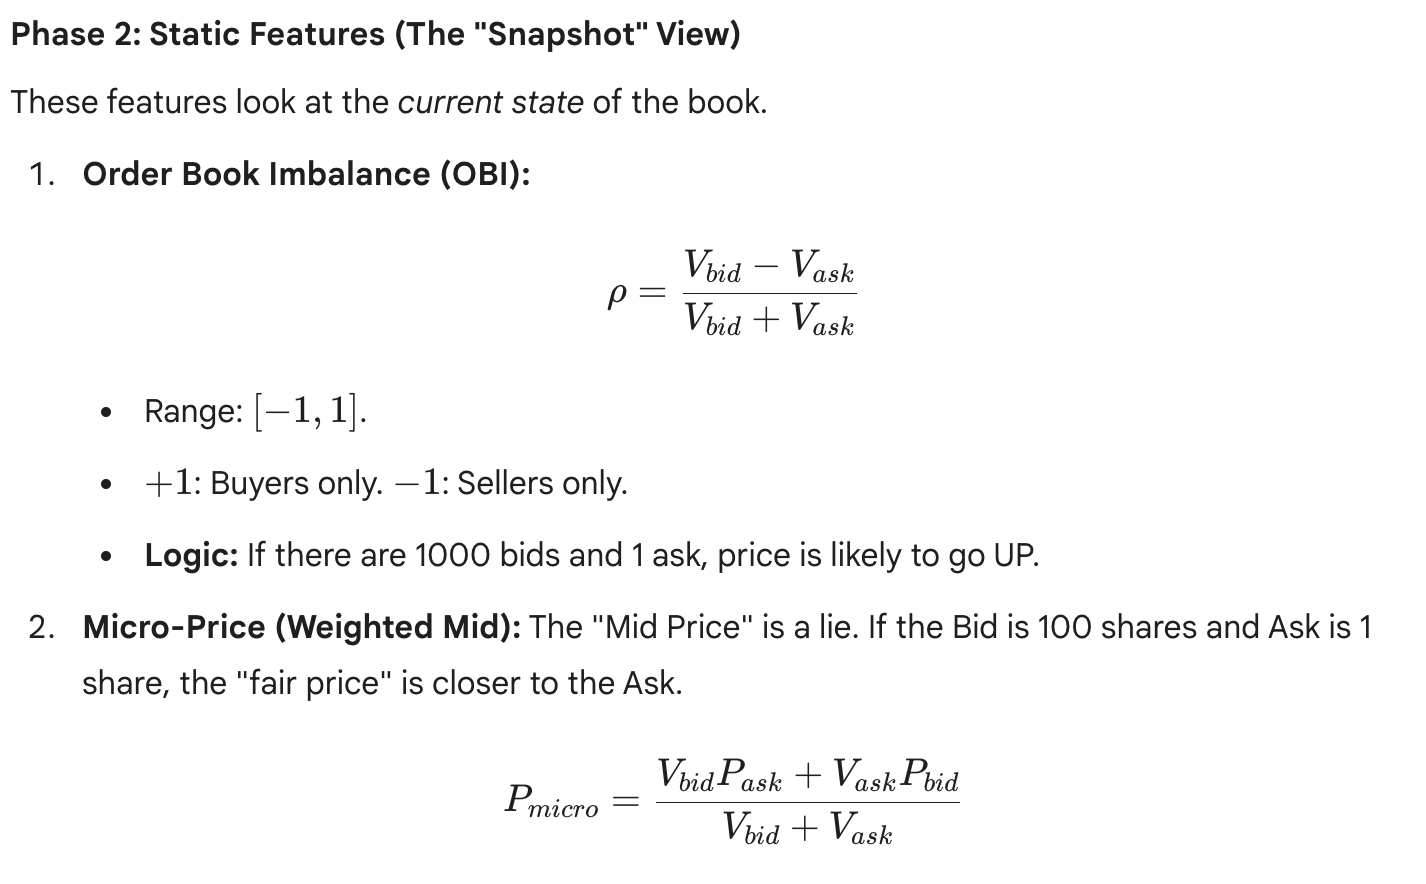

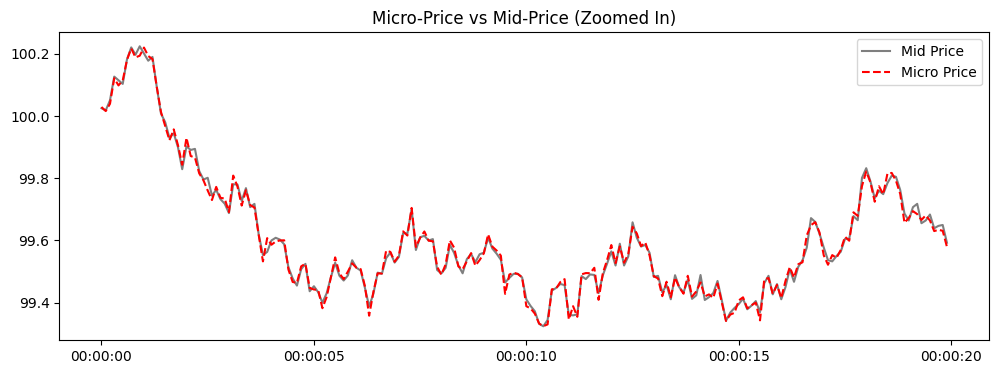

In [3]:
def calculate_static_features(df):
    df = df.copy()

    # 1. Standard Mid Price
    df['mid_px'] = (df['bid_px'] + df['ask_px']) / 2

    # 2. Order Book Imbalance (OBI)
    # Normalized between -1 (Bearish) and +1 (Bullish)
    df['OBI'] = (df['bid_size'] - df['ask_size']) / (df['bid_size'] + df['ask_size'])

    # 3. Micro-Price
    # Note the cross-multiplication: Bid Vol weights Ask Price (and vice versa)
    # Logic: If Bid Vol is huge, fair price is pushed towards Ask Price.
    df['micro_px'] = (
        (df['bid_size'] * df['ask_px']) + (df['ask_size'] * df['bid_px'])
    ) / (df['bid_size'] + df['ask_size'])

    # 4. Micro-Deviation (Signal)
    # How far is the Micro-Price from the Mid-Price?
    df['micro_deviation'] = df['micro_px'] - df['mid_px']

    return df

features_df = calculate_static_features(raw_df)

# Plotting the Alpha
plt.figure(figsize=(12, 4))
plt.plot(features_df['timestamp'][:200], features_df['mid_px'][:200], label='Mid Price', color='black', alpha=0.5)
plt.plot(features_df['timestamp'][:200], features_df['micro_px'][:200], label='Micro Price', color='red', linestyle='--')
plt.title("Micro-Price vs Mid-Price (Zoomed In)")
plt.legend()
plt.show()

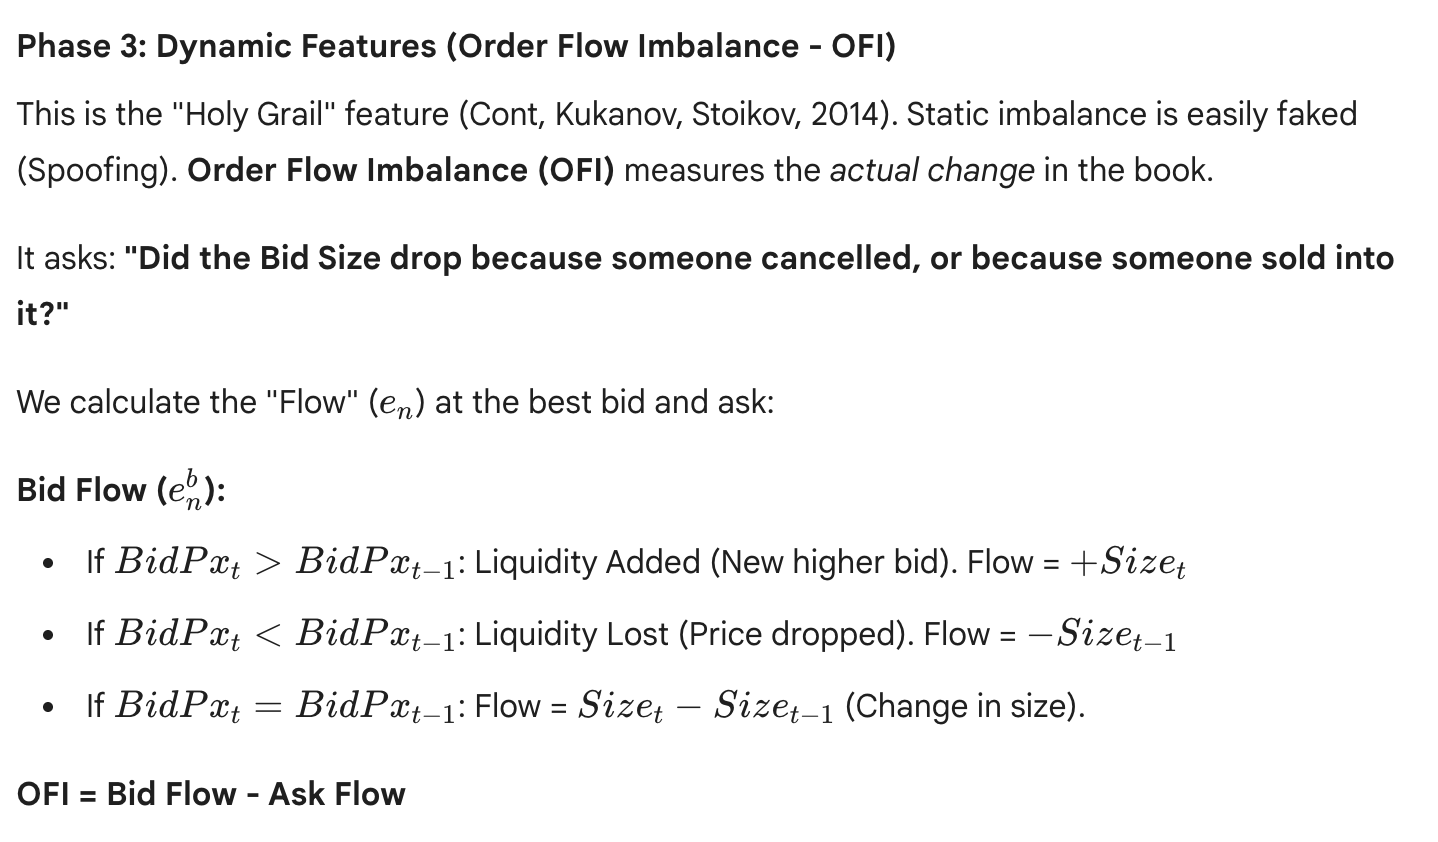

In [5]:
def calculate_ofi(df):
    # We need shifted columns to compare t vs t-1
    prev_bid_px = df['bid_px'].shift(1)
    prev_bid_sz = df['bid_size'].shift(1)
    prev_ask_px = df['ask_px'].shift(1)
    prev_ask_sz = df['ask_size'].shift(1)

    # --- 1. BID FLOW ---
    bid_flow = pd.Series(0.0, index=df.index)

    # Case 1: Price moved UP (Strong Buy pressure)
    bid_flow[df['bid_px'] > prev_bid_px] = df['bid_size']

    # Case 2: Price moved DOWN (Support collapsed)
    bid_flow[df['bid_px'] < prev_bid_px] = -prev_bid_sz

    # Case 3: Price same (Change in depth)
    bid_flow[df['bid_px'] == prev_bid_px] = df['bid_size'] - prev_bid_sz

    # --- 2. ASK FLOW ---
    ask_flow = pd.Series(0.0, index=df.index)

    # Case 1: Price moved UP (Resistance lifted)
    ask_flow[df['ask_px'] > prev_ask_px] = -prev_ask_sz

    # Case 2: Price moved DOWN (Strong Sell pressure)
    ask_flow[df['ask_px'] < prev_ask_px] = df['ask_size']

    # Case 3: Price same
    ask_flow[df['ask_px'] == prev_ask_px] = df['ask_size'] - prev_ask_sz

    # --- 3. NET OFI ---
    # OFI = Bid Flow - Ask Flow
    # High OFI = Bids increasing + Asks decreasing = BUY SIGNAL
    df['OFI'] = bid_flow - ask_flow

    # Accumulate OFI (Cumulative Flow often tracks Price)
    df['Cumulative_OFI'] = df['OFI'].cumsum()

    return df

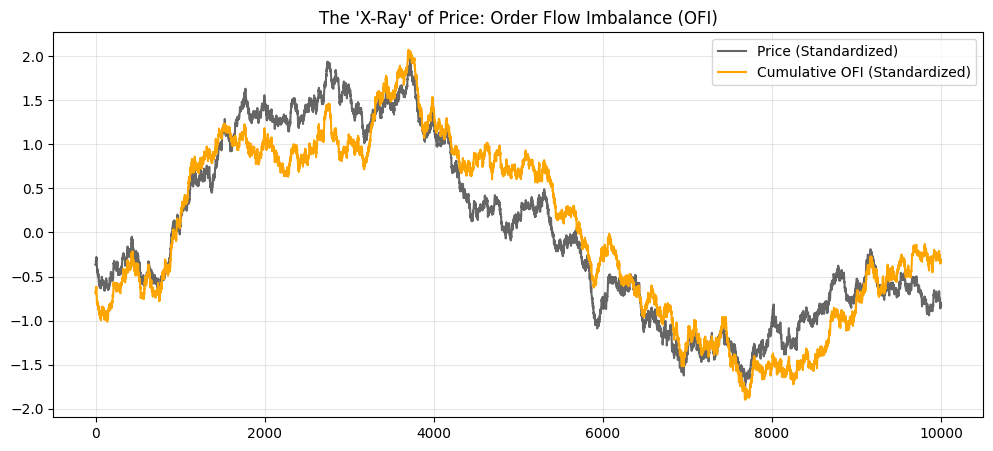

In [10]:
full_df = calculate_ofi(features_df).dropna()

# --- VISUALIZATION: THE PREDICTIVE POWER ---
# We standardize both series to plot them on one chart
def z_score(series):
    return (series - series.mean()) / series.std()

plt.figure(figsize=(12, 5))
plt.plot(z_score(full_df['mid_px']), label='Price (Standardized)', color='black', alpha=0.6)
plt.plot(z_score(full_df['Cumulative_OFI']), label='Cumulative OFI (Standardized)', color='orange')
plt.title("The 'X-Ray' of Price: Order Flow Imbalance (OFI)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

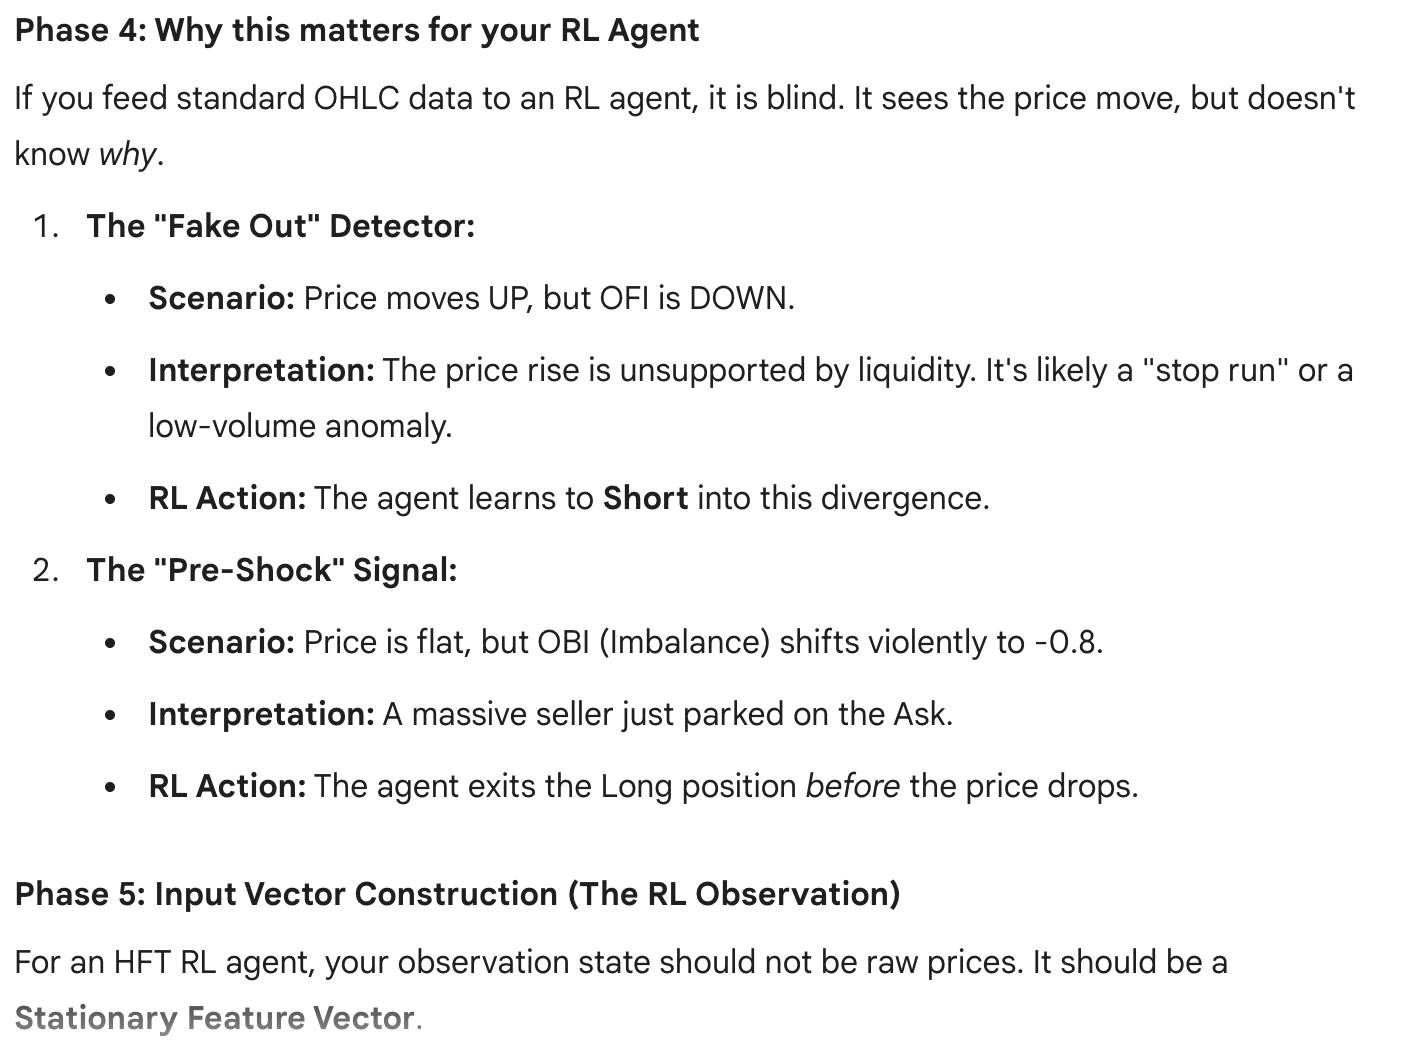